--- Data Overview ---
        0              Stream   Zscore          3            4     5  \
0  284392            COMMERCE    -0.03  323 (NEW)  28967 (NEW)  2020   
1  284393            COMMERCE   1.4422   53 (NEW)   4389 (NEW)  2020   
2  284394  BIOLOGICAL SCIENCE   1.2623   52 (NEW)   4307 (NEW)  2020   
3  284395                   -        -          -            -  2020   
4  284396            COMMERCE  -0.3608  412 (NEW)  35486 (NEW)  2020   

                                        6  7                 8  9          10  \
0  INFORMATION & COMMUNICATION TECHNOLOGY  S  BUSINESS STUDIES  C  ACCOUNTING   
1                               ECONOMICS  A  BUSINESS STUDIES  A  ACCOUNTING   
2                                 PHYSICS  C         CHEMISTRY  B     BIOLOGY   
3                                 PHYSICS  F         CHEMISTRY  S     BIOLOGY   
4                               ECONOMICS  S  BUSINESS STUDIES  S  ACCOUNTING   

  11  12 13   14  15        16    17  Gender  
0  S  50  S

/tmp/ipykernel_1304/1552990610.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analytics_summary, x='Stream', y='Zscore', palette='viridis')


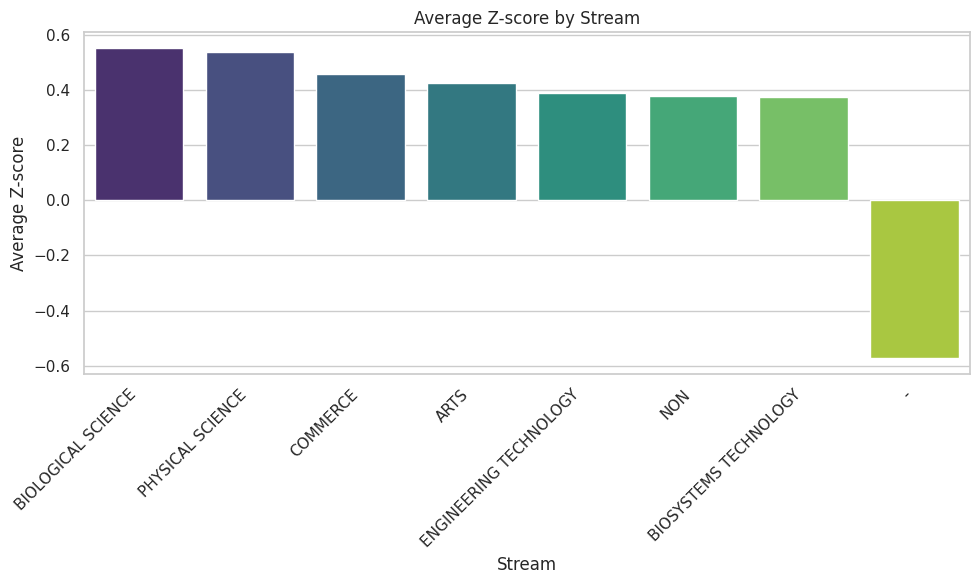

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. EXTRACT ---
# Read the uploaded CSV file, skipping the first row (which appears to be metadata or a problematic header)
# and assuming comma as delimiter. No header in the data rows themselves.
file_path = '/2020_al_data_kaggle_upload_new_old_syllabi.csv'
df = pd.read_csv(file_path, sep=',', header=None, skiprows=[0])

# Rename columns based on the expected structure of the dataset
# Assuming column 1 (index 0) is 'Student Id',
# column 2 (index 1) is 'Stream',
# column 3 (index 2) is 'Zscore'.
# Column 18 (index 18) is 'Gender'.
df.rename(columns={1: 'Stream', 2: 'Zscore', 18: 'Gender'}, inplace=True)

print("--- Data Overview ---")
print(df.head()) # Display the first 5 rows
print("\n--- DataFrame Info ---")
df.info()


# --- 2. TRANSFORM ---
# 1. Convert 'Zscore' to numeric, coercing errors to NaN
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')

# 2. Remove missing values (NaNs) from 'Stream' and 'Zscore' to ensure clean analysis
df_clean = df.dropna(subset=['Stream', 'Zscore', 'Gender']).copy()


# --- 3. LOAD / ANALYTICS ---
# Group data by 'Stream' and calculate the mean 'Zscore'
analytics_summary = df_clean.groupby('Stream')['Zscore'].mean().reset_index()

# Sort by Average Zscore
analytics_summary = analytics_summary.sort_values(by='Zscore', ascending=False)

print("\n--- Analytics Summary (Average Z-score by Stream) ---")
print(analytics_summary)

# Export the processed summary to a new CSV file
analytics_summary.to_csv('stream_zscore_analytics.csv', index=False)


# --- 4. DATA VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.barplot(data=analytics_summary, x='Stream', y='Zscore', palette='viridis')
plt.title('Average Z-score by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Data Extraction Part

In [44]:
# --- 1. EXTRACT ---
file_path = '/2020_al_data_kaggle_upload_new_old_syllabi.csv'
df = pd.read_csv(file_path, sep=',', header=None, skiprows=[0])
df.rename(columns={1: 'Stream', 2: 'Zscore', 18: 'Gender'}, inplace=True)
print("--- Data Overview ---")
print(df.head())
print("\n--- DataFrame Info ---")
df.info()

--- Data Overview ---
        0              Stream   Zscore          3            4     5  \
0  284392            COMMERCE    -0.03  323 (NEW)  28967 (NEW)  2020   
1  284393            COMMERCE   1.4422   53 (NEW)   4389 (NEW)  2020   
2  284394  BIOLOGICAL SCIENCE   1.2623   52 (NEW)   4307 (NEW)  2020   
3  284395                   -        -          -            -  2020   
4  284396            COMMERCE  -0.3608  412 (NEW)  35486 (NEW)  2020   

                                        6  7                 8  9          10  \
0  INFORMATION & COMMUNICATION TECHNOLOGY  S  BUSINESS STUDIES  C  ACCOUNTING   
1                               ECONOMICS  A  BUSINESS STUDIES  A  ACCOUNTING   
2                                 PHYSICS  C         CHEMISTRY  B     BIOLOGY   
3                                 PHYSICS  F         CHEMISTRY  S     BIOLOGY   
4                               ECONOMICS  S  BUSINESS STUDIES  S  ACCOUNTING   

  11  12 13   14  15        16    17  Gender  
0  S  50  S

### Data Cleaning Part (Transform)

In [43]:
# --- 2. TRANSFORM ---
# 1. Convert 'Zscore' to numeric, coercing errors to NaN
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')
# 2. Remove missing values (NaNs) from 'Stream', 'Zscore', and 'Gender'
df_clean = df.dropna(subset=['Stream', 'Zscore', 'Gender']).copy()

In [41]:
# --- 3.2. LOAD / ANALYTICS (Pivot Table: Gender vs. Stream) ---
# Create a pivot table to compare average Z-scores by Gender and Stream
pivot_table_gender_stream = pd.pivot_table(
    df_clean,
    values='Zscore',
    index='Gender',
    columns='Stream',
    aggfunc='mean'
)

print("\n--- Pivot Table: Average Z-score by Gender and Stream ---")
display(pivot_table_gender_stream)

# Optional: Export the pivot table to a CSV file
pivot_table_gender_stream.to_csv('gender_stream_zscore_pivot.csv')



--- Pivot Table: Average Z-score by Gender and Stream ---


Stream,-,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,NON,PHYSICAL SCIENCE
Gender,,,,,,,,
Major error,-1.090167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
female,-0.565982,0.462881,0.529394,0.378128,0.513998,0.440136,0.309366,0.442705
male,-0.581718,0.299135,0.620941,0.366080,0.373379,0.378900,0.473278,0.592079


In [46]:
gender_pivot_df = pd.read_csv('gender_stream_zscore_pivot.csv')
display(gender_pivot_df.head())

,Gender,-,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,NON,PHYSICAL SCIENCE
0,Major error,-1.090167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,female,-0.565982,0.462881,0.529394,0.378128,0.513998,0.440136,0.309366,0.442705
2,male,-0.581718,0.299135,0.620941,0.366080,0.373379,0.378900,0.473278,0.592079


In [47]:
display(df_clean.head())

,0,Stream,Zscore,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,Gender
0,284392,COMMERCE,-0.0300,323 (NEW),28967 (NEW),2020,INFORMATION & COMMUNICATION TECHNOLOGY,S,BUSINESS STUDIES,C,ACCOUNTING,S,50,S,new,5,February,2001,female
1,284393,COMMERCE,1.4422,53 (NEW),4389 (NEW),2020,ECONOMICS,A,BUSINESS STUDIES,A,ACCOUNTING,A,48,S,new,17,December,2001,female
2,284394,BIOLOGICAL SCIENCE,1.2623,52 (NEW),4307 (NEW),2020,PHYSICS,C,CHEMISTRY,B,BIOLOGY,C,74,A,new,10,August,2001,female
4,284396,COMMERCE,-0.3608,412 (NEW),35486 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,F,new,2,October,2001,female
5,284397,PHYSICAL SCIENCE,0.9885,66 (NEW),6416 (NEW),2020,PHYSICS,C,CHEMISTRY,C,COMBINED MATHEMATICS,C,62,A,new,3,October,2001,female
